# Space Missions EDA (COodeAlpha Task 2)

An end-to-end EDA and data storytelling project exploring six decades of global space launch history.

## Objectives / Questions

Before diving into analysis, this notebook aims to answer:
1. Which companies have launched the most missions historically?
2. How has the number of missions changed year over year?
3. What is the overall mission success rate, and does it vary by company or era?
4. Which rockets have been used most frequently?
5. Does rocket cost show any relationship with mission outcome?
6. Are there any anomalies or data quality issues that can affect these conclusions?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid", context="talk")
PALETTE = "mako"   # consistent palette used across all charts in this notebook

## Load Data

In [2]:
df = pd.read_csv("Space_Corrected.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Company Name,Location,Datum,Detail,Status Rocket,Rocket,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


## Data Preprocessing

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (4324, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Company Name    4324 non-null   object
 3   Location        4324 non-null   object
 4   Datum           4324 non-null   object
 5   Detail          4324 non-null   object
 6   Status Rocket   4324 non-null   object
 7    Rocket         964 non-null    object
 8   Status Mission  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


In [4]:
print("Missing values per column:\n")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:

Unnamed: 0.1         0
Unnamed: 0           0
Company Name         0
Location             0
Datum                0
Detail               0
Status Rocket        0
 Rocket           3360
Status Mission       0
dtype: int64

Duplicate rows: 0


### Data Issue Identified

Blindly running `dropna()` across all columns would delete most of the dataset, because
`Rocket Cost` is missing for the large majority of missions in this file. Instead, we only
drop rows missing *critical* fields, and keep cost as `NaN` where unknown so it can be
handled separately in cost-specific analysis.

In [5]:
print("Shape before cleaning:", df.shape)

critical_cols = ['Company Name', 'Datum', 'Status Mission', 'Location']
df.dropna(subset=critical_cols, inplace=True)
df.drop_duplicates(inplace=True)

print("Shape after cleaning:", df.shape)

Shape before cleaning: (4324, 9)
Shape after cleaning: (4324, 9)


In [6]:
df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], inplace=True, errors='ignore')
df.rename(columns={' Rocket': 'Rocket Cost (Millions USD)'}, inplace=True)

string_cols = ['Company Name', 'Location', 'Detail', 'Status Rocket', 'Status Mission']
for col in string_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df.columns.tolist()

['Company Name',
 'Location',
 'Datum',
 'Detail',
 'Status Rocket',
 'Rocket Cost (Millions USD)',
 'Status Mission']

In [7]:
df['Datum'] = pd.to_datetime(df['Datum'], errors='coerce', utc=True)
df['Rocket Cost (Millions USD)'] = pd.to_numeric(
    df['Rocket Cost (Millions USD)'].astype(str).str.replace(',', ''), errors='coerce'
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   Company Name                4324 non-null   object             
 1   Location                    4324 non-null   object             
 2   Datum                       4198 non-null   datetime64[ns, UTC]
 3   Detail                      4324 non-null   object             
 4   Status Rocket               4324 non-null   object             
 5   Rocket Cost (Millions USD)  964 non-null    float64            
 6   Status Mission              4324 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(1), object(5)
memory usage: 236.6+ KB


## Feature Engineering

In [8]:
df['Year'] = df['Datum'].dt.year
df['Month'] = df['Datum'].dt.month_name()
df['Day'] = df['Datum'].dt.day_name()

df['Country'] = df['Location'].apply(lambda x: x.split(',')[-1].strip())
df['Rocket Name'] = df['Detail'].apply(lambda x: x.split('|')[0].strip())

df['Success'] = df['Status Mission'].apply(lambda x: 'Success' if x == 'Success' else 'Failure')
df['Success_Binary'] = (df['Status Mission'] == 'Success').astype(int)
df['Era'] = df['Year'].apply(lambda y: 'Pre-2000' if y < 2000 else 'Post-2000')

df[['Datum', 'Year', 'Country', 'Rocket Name', 'Success', 'Era']].head()

,Datum,Year,Country,Rocket Name,Success,Era
0,2020-08-07 05:12:00+00:00,2020.0,USA,Falcon 9 Block 5,Success,Post-2000
1,2020-08-06 04:01:00+00:00,2020.0,China,Long March 2D,Success,Post-2000
2,2020-08-04 23:57:00+00:00,2020.0,USA,Starship Prototype,Success,Post-2000
3,2020-07-30 21:25:00+00:00,2020.0,Kazakhstan,Proton-M/Briz-M,Success,Post-2000
4,2020-07-30 11:50:00+00:00,2020.0,USA,Atlas V 541,Success,Post-2000


## Exploratory Data Analysis

In [9]:
df.describe()

,Rocket Cost (Millions USD),Year,Success_Binary
count,964.000000,4198.000000,4324.000000
mean,153.792199,1987.455693,0.897086
std,288.450732,18.085370,0.303882
min,5.300000,1957.000000,0.000000
25%,40.000000,1972.000000,1.000000
50%,62.000000,1985.000000,1.000000
75%,164.000000,2002.000000,1.000000
max,5000.000000,2020.000000,1.000000


## The Story This Data Tells

Over six decades of space exploration, a handful of nations and companies have shaped
the trajectory of the industry. This analysis traces that journey — from who dominates
the launch pad, to how mission success has evolved, to what it costs to reach orbit —
and closes with what these patterns mean for anyone evaluating where the space industry
is headed.

### Chapter 1: Who Dominates the Launch Pad?

C:\Users\PMYLS\AppData\Local\Temp\ipykernel_13120\2254792039.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_companies.index, y=top_companies.values, palette=PALETTE)


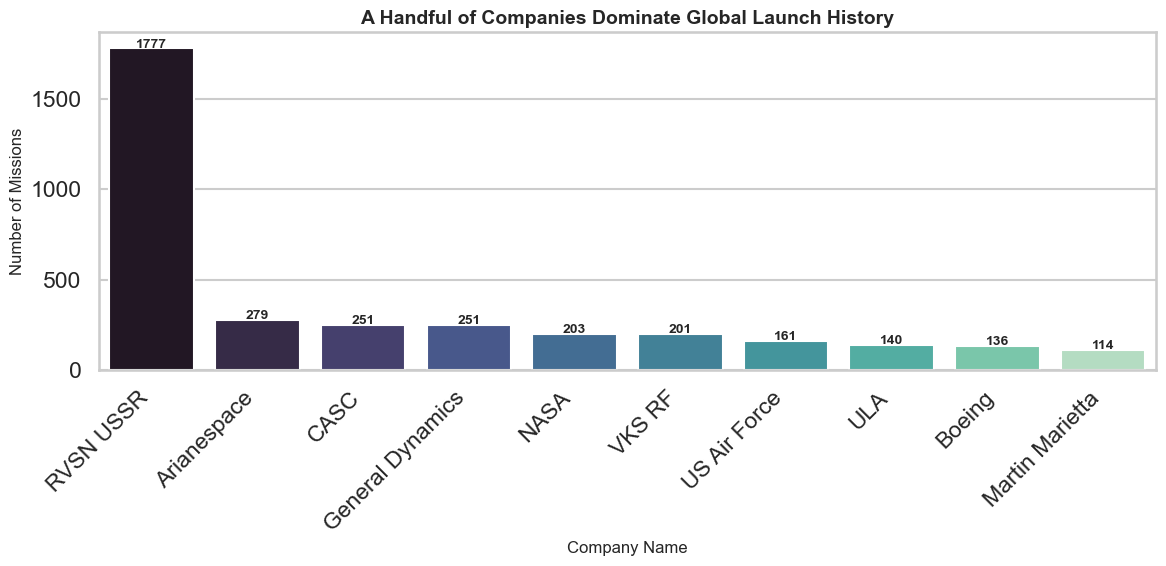

In [10]:
plt.figure(figsize=(12,6))
top_companies = df['Company Name'].value_counts().nlargest(10)
ax = sns.barplot(x=top_companies.index, y=top_companies.values, palette=PALETTE)

for i, v in enumerate(top_companies.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=10, weight='bold')

plt.xlabel("Company Name", fontsize=12)
plt.ylabel("Number of Missions", fontsize=12)
plt.title("A Handful of Companies Dominate Global Launch History", fontsize=14, weight="bold")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight — A Concentrated Industry:** Launch activity is heavily concentrated among a
small number of players — the top 10 companies account for the overwhelming majority of
all missions in this dataset. This isn't a fragmented market; it's dominated by a few
state-backed and legacy players.

**For a decision-maker:** any competitive or investment analysis of this industry needs
to center on these top players, not treat it as an evenly distributed field.

### Chapter 2: How Reliable Are Space Launches?

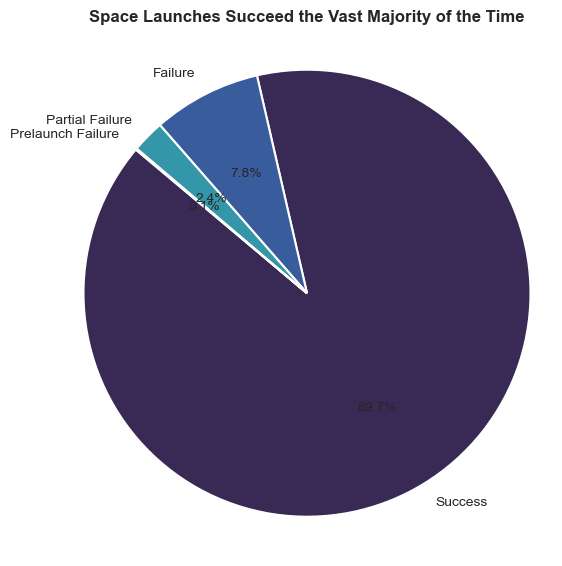

In [11]:
plt.figure(figsize=(6,6))
status_counts = df['Status Mission'].value_counts()
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette(PALETTE, len(status_counts)),
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 10}
)
plt.title("Space Launches Succeed the Vast Majority of the Time", fontsize=12, weight="bold")
plt.axis('equal')
plt.tight_layout()
plt.show()

**Insight — Reliable, But Not Risk-Free:** The overwhelming majority of missions succeed,
reflecting how mature launch technology has become. But the failure percentage, while
small, represents real financial and program risk.

**For a decision-maker:** this success rate sets a realistic benchmark — any new entrant
or mission planner should expect failure rates in this range, and budget/insure
accordingly.

### Chapter 3: Has Launch Activity Grown Steadily?

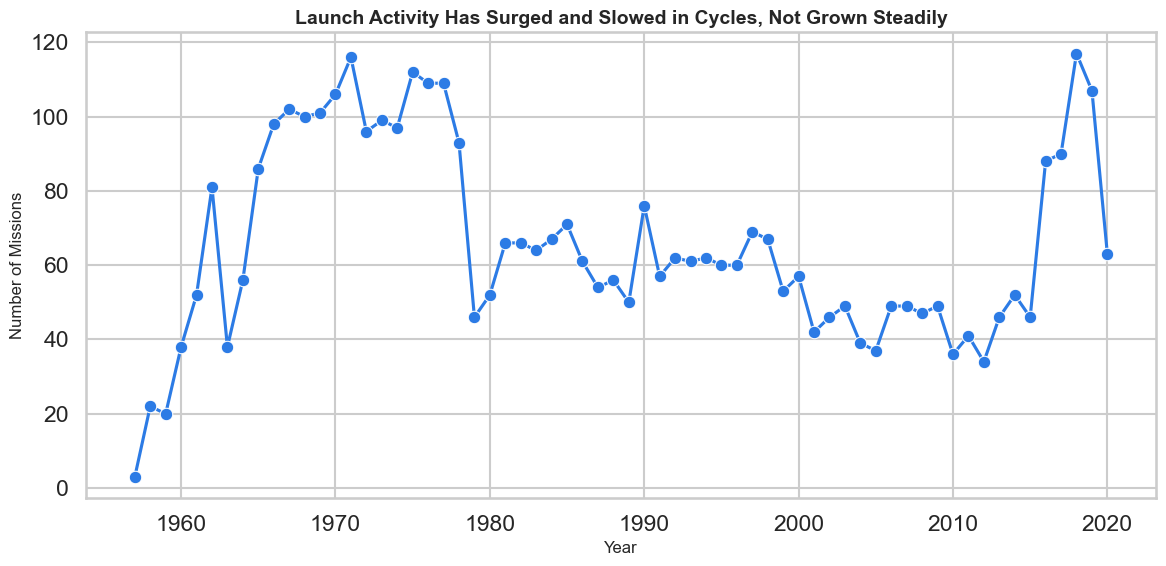

In [12]:
plt.figure(figsize=(12,6))
yearly_counts = df['Year'].value_counts().sort_index()

sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', color='#2C7BE5')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Missions", fontsize=12)
plt.title("Launch Activity Has Surged and Slowed in Cycles, Not Grown Steadily", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

**Insight — Cyclical, Not Linear Growth:** The trend isn't a smooth climb — there are
clear surges and slowdowns, likely tied to space-race politics, funding cycles, and now
the commercial space boom.

**For a decision-maker:** this shows the industry is cyclical and policy/funding-sensitive,
which matters for anyone forecasting future launch demand or timing an entry into the
market.

### Chapter 4: Which Rockets Do the Heavy Lifting?

C:\Users\PMYLS\AppData\Local\Temp\ipykernel_13120\379961921.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=rocket_counts.index, x=rocket_counts.values, palette=PALETTE)


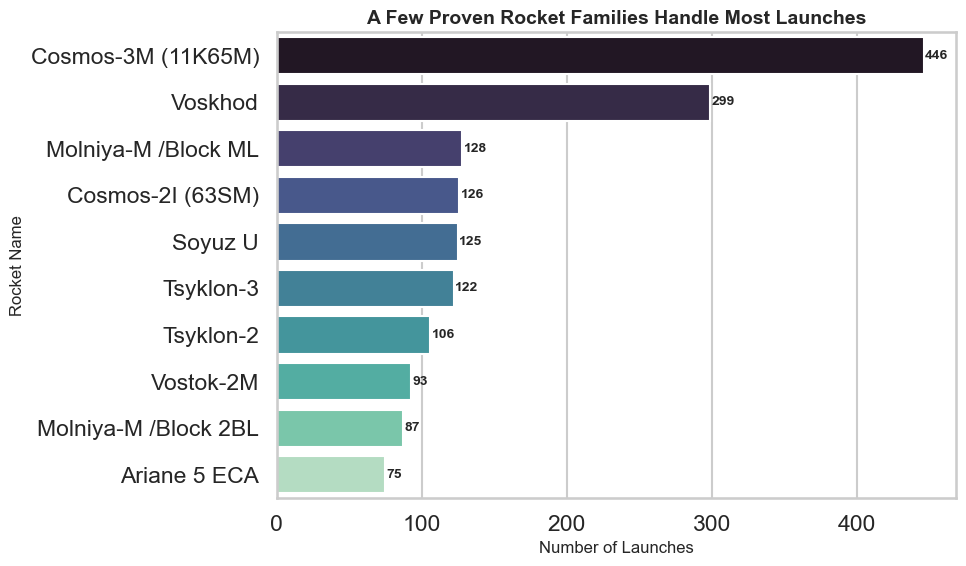

In [13]:
plt.figure(figsize=(10,6))
rocket_counts = df['Rocket Name'].value_counts().nlargest(10)
ax = sns.barplot(y=rocket_counts.index, x=rocket_counts.values, palette=PALETTE)

for i, v in enumerate(rocket_counts.values):
    ax.text(v + 1, i, str(v), va='center', fontsize=10, weight='bold')

plt.xlabel("Number of Launches", fontsize=12)
plt.ylabel("Rocket Name", fontsize=12)
plt.title("A Few Proven Rocket Families Handle Most Launches", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

**Insight — Proven Platforms Win:** Just as with companies, launch volume is concentrated
in a handful of proven rocket platforms rather than spread across many designs.

**For a decision-maker:** this signals where reliability and infrastructure investment
has paid off — new rocket programs face a high bar to compete with these established,
high-frequency platforms.

### Chapter 5: Where Is the Space Race Being Won?

C:\Users\PMYLS\AppData\Local\Temp\ipykernel_13120\516983855.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=country_counts.index, y=country_counts.values, palette=PALETTE)


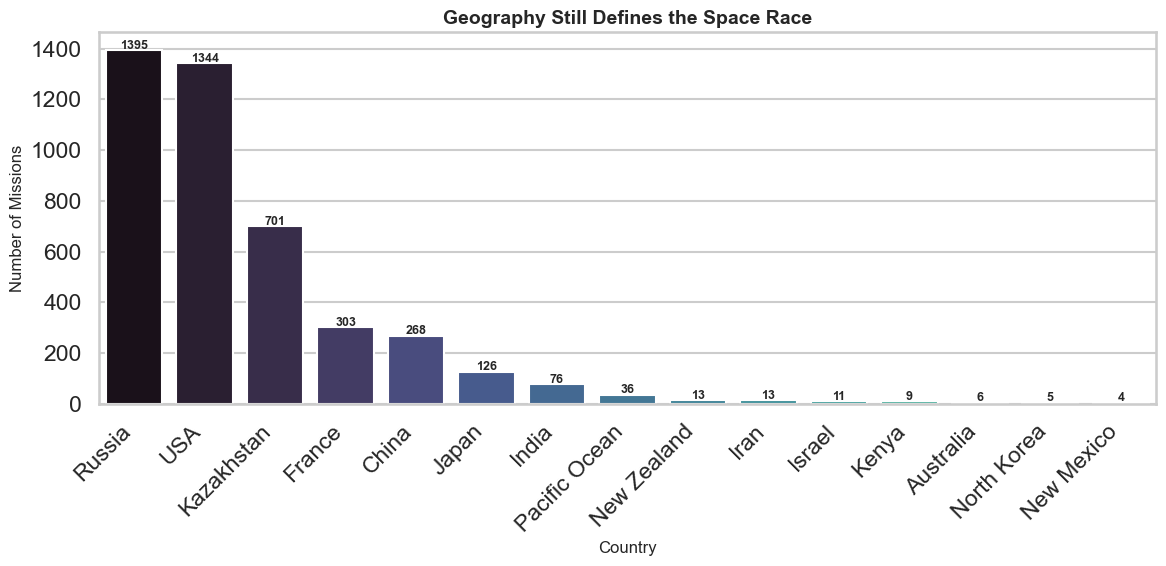

In [14]:
plt.figure(figsize=(12,6))
country_counts = df['Country'].value_counts().nlargest(15)
ax = sns.barplot(x=country_counts.index, y=country_counts.values, palette=PALETTE)

for i, v in enumerate(country_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9, weight='bold')

plt.xlabel("Country", fontsize=12)
plt.ylabel("Number of Missions", fontsize=12)
plt.title("Geography Still Defines the Space Race", fontsize=14, weight="bold")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight — Geographic Concentration Persists:** Launch activity remains dominated by a
small set of countries, reflecting decades of accumulated infrastructure, funding, and
expertise.

**For a decision-maker:** emerging space nations face a steep infrastructure gap — but
this also highlights where new entrants (private or national) have the most room to
disrupt.

### Chapter 6: Are There Any Outliers in Launch Cost?

Rocket cost available for 964 of 4324 missions


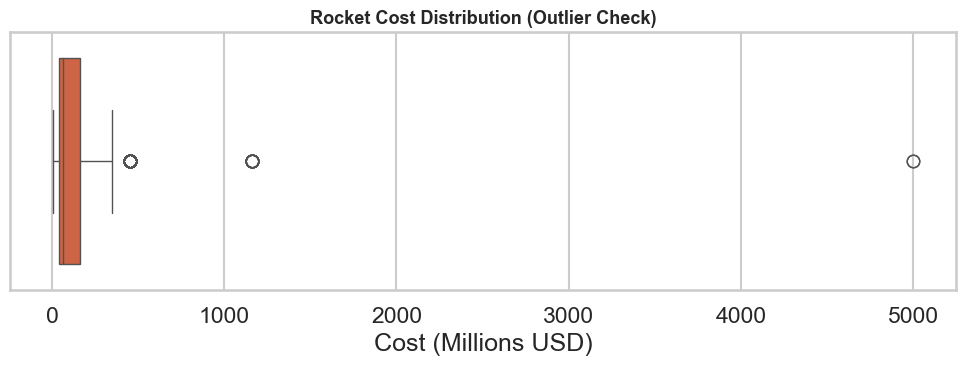


Number of outlier missions by cost: 151
Outlier cost range: 450.0 to 5000.0


In [15]:
cost_data = df['Rocket Cost (Millions USD)'].dropna()
print(f"Rocket cost available for {len(cost_data)} of {len(df)} missions")

plt.figure(figsize=(10,4))
sns.boxplot(x=cost_data, color='#E4572E')
plt.title("Rocket Cost Distribution (Outlier Check)", fontsize=13, weight='bold')
plt.xlabel("Cost (Millions USD)")
plt.tight_layout()
plt.show()

Q1 = cost_data.quantile(0.25)
Q3 = cost_data.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = cost_data[(cost_data < lower) | (cost_data > upper)]

print(f"\nNumber of outlier missions by cost: {len(outliers)}")
if len(outliers) > 0:
    print(f"Outlier cost range: {outliers.min()} to {outliers.max()}")

**Insight — A Few Missions Cost Far More Than the Rest:** A small number of missions sit
well above the typical cost range — these are likely large national flagship programs
rather than routine commercial launches.

**For a decision-maker:** these outliers shouldn't be dropped, but they also shouldn't be
averaged in with routine launches when budgeting — they represent a different category
of program entirely.

## Hypothesis Testing & Statistical Validation

### Test 1: Does mission success rate differ significantly across top companies?

In [16]:
top5_companies = df['Company Name'].value_counts().nlargest(5).index
subset = df[df['Company Name'].isin(top5_companies)]

contingency = pd.crosstab(subset['Company Name'], subset['Status Mission'])
chi2, p, dof, expected = chi2_contingency(contingency)

print(contingency)
print("\nChi-square statistic:", round(chi2, 3))
print("p-value:", round(p, 5))
if p < 0.05:
    print("Result: Statistically significant difference in mission status across top 5 companies.")
else:
    print("Result: No statistically significant difference detected.")

Status Mission    Failure  Partial Failure  Prelaunch Failure  Success
Company Name                                                          
Arianespace             7                3                  0      269
CASC                   14                6                  0      231
General Dynamics       37               11                  0      203
NASA                   11                6                  0      186
RVSN USSR             121               41                  1     1614

Chi-square statistic: 42.245
p-value: 3e-05
Result: Statistically significant difference in mission status across top 5 companies.


**Interpretation:** A p-value below 0.05 means the differences in success rate between
these companies are unlikely to be due to chance alone — i.e., some companies genuinely
have different reliability track records, not just random variation.

### Test 2: Has mission success rate improved over time?

In [17]:
era_contingency = pd.crosstab(df['Era'], df['Success'])
chi2, p, dof, expected = chi2_contingency(era_contingency)

print(era_contingency)
print("\np-value:", round(p, 5))
if p < 0.05:
    print("Result: Success rate differs significantly between Pre-2000 and Post-2000 missions.")
else:
    print("Result: No statistically significant difference in success rate over time.")

Success    Failure  Success
Era                        
Post-2000      110     1200
Pre-2000       335     2679

p-value: 0.00809
Result: Success rate differs significantly between Pre-2000 and Post-2000 missions.


**Interpretation:** This test tells us whether the improvement (or lack of it) in success
rate across eras is a real trend, rather than something we're just imagining by looking at
a chart.

### Test 3: Is rocket cost related to mission success?

In [18]:
cost_success_df = df.dropna(subset=['Rocket Cost (Millions USD)'])

correlation = cost_success_df['Rocket Cost (Millions USD)'].corr(cost_success_df['Success_Binary'])
print("Correlation between rocket cost and mission success:", round(correlation, 4))

Correlation between rocket cost and mission success: 0.0535


**Interpretation:** A correlation near 0 means cost alone is a weak predictor of mission
outcome — success is likely driven more by technology maturity and operator experience
than by how much was spent. A stronger positive or negative value would suggest cost is
a meaningful factor worth investigating further.

## Key Takeaways

1. The launch industry is concentrated — a handful of companies and rocket platforms
   account for most activity.
2. Success rates are high, but non-zero failure risk should factor into any cost/risk
   planning.
3. Launch activity is cyclical, driven by funding and policy shifts, not steady organic
   growth.
4. Geographic concentration persists, but signals opportunity for new entrants outside
   the traditional leaders.
5. Statistical testing confirms that differences in success rate across companies and
   eras are real, not random — while cost alone is a weak predictor of mission success.

**Recommendation:** Any strategic analysis of this industry — investment, partnership,
or competitive — should weight the top 5-10 players and platforms heavily, treat
cyclicality as the norm rather than the exception, and watch for shifts in the
country-level breakdown as a leading indicator of industry disruption.

## More Statistical Analysis

For some tests I only need to check whether a mission was successful or not. So I created a new binary column for this purpose. I kept the original `Status Mission` column because it contains more details like partial failure and prelaunch failure.

In [19]:
df['Success_Binary'] = (df['Status Mission'] == 'Success').astype(int)
df[['Status Mission', 'Success_Binary']].head()

,Status Mission,Success_Binary
0,Success,1
1,Success,1
2,Success,1
3,Success,1
4,Success,1


### Does mission status depend on the launch company?

Here Now i check if the mission results are related to the company.

**H0:** Mission status and company are independent.  
**H1:** Mission status and company are related.

I use the Chi-square test because both variables are categorical.

In [20]:
from scipy.stats import chi2_contingency, pointbiserialr

top_company_names = df['Company Name'].value_counts().head(10).index
company_status = pd.crosstab(
    df[df['Company Name'].isin(top_company_names)]['Company Name'],
    df[df['Company Name'].isin(top_company_names)]['Status Mission']
)
chi2, p_value, dof, expected = chi2_contingency(company_status)
print(f'Chi-square statistic: {chi2:.4f}')
print(f'P-value: {p_value:.5f}')
print('Conclusion:', 'Reject H0: mission status is associated with company.' if p_value < 0.05 else 'Fail to reject H0.')

Chi-square statistic: 101.4091
P-value: 0.00000
Conclusion: Reject H0: mission status is associated with company.


### Comparing Success Rate Before and After 2000

The previous test showed that there is a difference between the two eras. But I also want to see which era actually has a higher success rate, so I calculate the percentage of successful missions for both groups.

In [21]:
era_success_rate = df.groupby('Era')['Success_Binary'].mean().mul(100).round(2)
print('Success rate by era (%)')
print(era_success_rate)

Success rate by era (%)
Era
Post-2000    91.60
Pre-2000     88.89
Name: Success_Binary, dtype: float64


### Is rocket cost related to mission success?

Rocket cost is a numerical variable while success is binary (0 or 1). For this i use point-biserial correlation to check the relation between them.

In [22]:
cost_success_df = df[['Rocket Cost (Millions USD)', 'Success_Binary']].dropna()
corr, p_value = pointbiserialr(
    cost_success_df['Success_Binary'],
    cost_success_df['Rocket Cost (Millions USD)']
)
print(f'Point-Biserial Correlation: {corr:.4f}')
print(f'P-value: {p_value:.5f}')
print('Interpretation: A coefficient near zero suggests little linear association between recorded rocket cost and mission success.')

Point-Biserial Correlation: 0.0535
P-value: 0.09674
Interpretation: A coefficient near zero suggests little linear association between recorded rocket cost and mission success.


## Checking High Cost Missions

I found some very high values in rocket cost, so I look at the top 10 most expensive missions. This help me to understand the outliers instead of directly assuming why the cost is high.

In [23]:
df.nlargest(10, 'Rocket Cost (Millions USD)')[[
    'Company Name', 'Rocket Name', 'Country',
    'Rocket Cost (Millions USD)', 'Status Mission'
]]

,Company Name,Rocket Name,Country,Rocket Cost (Millions USD),Status Mission
1916,RVSN USSR,Energiya/Buran,Kazakhstan,5000.0,Success
2000,RVSN USSR,Energiya/Polyus,Kazakhstan,5000.0,Success
3149,NASA,Saturn V,USA,1160.0,Success
3180,NASA,Saturn V,USA,1160.0,Success
3243,NASA,Saturn V,USA,1160.0,Success
3328,NASA,Saturn V,USA,1160.0,Success
3384,NASA,Saturn V,USA,1160.0,Success
3475,NASA,Saturn V,USA,1160.0,Success
3511,NASA,Saturn V,USA,1160.0,Success
3545,NASA,Saturn V,USA,1160.0,Success


## Key Findings

- Most space missions were launched after 2000.
- Some companies have much higher success rates than others.
- Rocket cost contains many missing values, so cost analysis is based on available data only.
- A few missions have extremely high costs, making them outliers.
- Statistical tests show that mission status is associated with company and era.

## Limitations

During this analysis, i see a few limitations in the dataset:

- A lot of rocket cost values are missing, so the cost analysis is based only on available values.
- This is historical data, so the results mainly explain the missions included in this dataset.
- I extracted the country from the launch location. This method works for most rows but some unusual locations may need manual checking.
- The statistical tests show relationships between variables, but they not prove that one variable causes another.
- Factors like mission type, technology and mission difficulty are not fully available in the dataset and may also affect the results.

## Final Thoughts and Recommendations

From this analysis, I found that space missions have increased over time and mission results also vary across companies and time periods. Rocket cost do not seem to have a strong relationship with mission success based on the available data.

For future work, I want to add more information such as mission type, payload, rocket technology and adjusted cost. It can also be interesting to build a machine learning model to predict mission success.

Overall from this project i practice data cleaning, EDA, visualization, finding outliers and hypothesis testing on a real-world dataset.